In [6]:
import json

import matplotlib.pyplot as plt
import pandas as pd

In [7]:
df = pd.read_csv('../data/raw/ec2_cpu_utilization_24ae8d.csv', parse_dates=['timestamp'])
df = df.set_index('timestamp')

In [8]:
tamanho_treino = int(len(df) * 0.8)

treino = df.iloc[:tamanho_treino]
teste = df.iloc[tamanho_treino:]

print(f'Treino: {len(treino)} data points, de {treino.index.min()} até {treino.index.max()}')
print(f'Teste:  {len(teste)} data points, de {teste.index.min()} até {teste.index.max()}')

Treino: 3225 data points, de 2014-02-14 14:30:00 até 2014-02-25 19:10:00
Teste:  807 data points, de 2014-02-25 19:15:00 até 2014-02-28 14:25:00


In [11]:

with open('../data/labels/combined_windows.json') as f:
    labels = json.load(f)

windows = labels['realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv']
windows = [(pd.Timestamp(w[0]), pd.Timestamp(w[1])) for w in windows]

for start, end in windows:
    dentro_do_teste = start >= teste.index.min() and end <= teste.index.max()
    print(f'Janela {start} -> {end} | esta no conjunto de teste: {dentro_do_teste}')

Janela 2014-02-26 13:45:00 -> 2014-02-27 06:25:00 | esta no conjunto de teste: True
Janela 2014-02-27 08:55:00 -> 2014-02-28 01:35:00 | esta no conjunto de teste: True


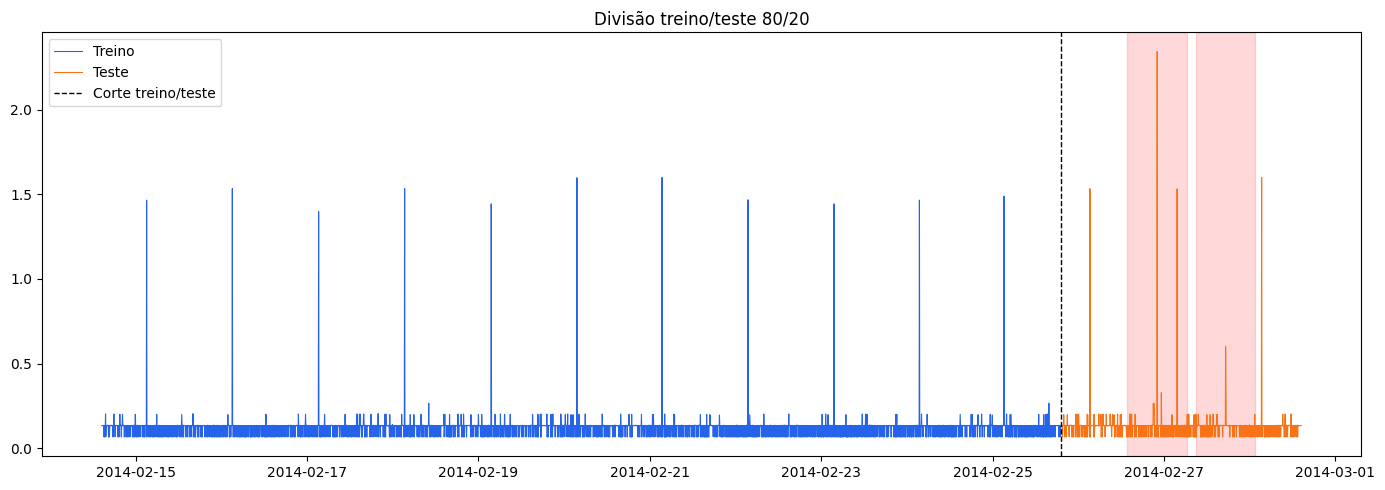

: 

In [ ]:

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(treino.index, treino['value'], label='Treino', color='#2563eb', linewidth=0.8)
ax.plot(teste.index, teste['value'], label='Teste', color='#f97316', linewidth=0.8)
for start, end in windows:
    ax.axvspan(start, end, color='red', alpha=0.15)
ax.axvline(teste.index.min(), color='black', linestyle='--', linewidth=1, label='Corte treino/teste')
ax.legend()
ax.set_title('Divisão treino/teste 80/20')
plt.tight_layout()
plt.show()